04_feature_selection.ipynb

1. Imports
2. Load Data (from 02b's corrected splits)
3. Chi-Square Test
4. LASSO (L1 Logistic Regression)
5. Random Forest Importance
6. Compare All Three Methods
7. Decide Final Feature Set
8. Save Outputs (csv, png) + Download

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_selection import chi2, SelectKBest
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

import warnings
warnings.filterwarnings("ignore")
plt.style.use("ggplot")

In [13]:
from google.colab import files
uploaded = files.upload()  # upload X_train_binary.csv, y_train_binary.csv (from 02b output)

X_train_bin = pd.read_csv("X_train_binary.csv")
X_test_bin = pd.read_csv("X_test_binary.csv")

y_train_bin = pd.read_csv("y_train_binary.csv").squeeze()
y_test_bin = pd.read_csv("y_test_binary.csv").squeeze()

print("Train:", X_train_bin.shape)
print("Test :", X_test_bin.shape)
print(X_train_bin.columns.tolist())

Saving X_test_binary.csv to X_test_binary.csv
Saving X_train_binary.csv to X_train_binary (1).csv
Saving y_test_binary.csv to y_test_binary.csv
Saving y_train_binary.csv to y_train_binary (1).csv
Train: (736, 17)
Test : (184, 17)
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'ca_missing', 'thal_missing', 'slope_missing', 'chol_missing']


In [3]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_train_bin)

chi_scores, p_values = chi2(X_scaled, y_train_bin)

chi_df = pd.DataFrame({
    "Feature": X_train_bin.columns,
    "Chi2 Score": chi_scores,
    "p-value": p_values
}).sort_values(by="Chi2 Score", ascending=False)

print(chi_df)

          Feature  Chi2 Score       p-value
8           exang   85.667872  2.128431e-20
16   chol_missing   36.884323  1.253498e-09
15  slope_missing   29.993047  4.335982e-08
12           thal   28.331625  1.022124e-07
2              cp   19.474983  1.019259e-05
11             ca   16.682955  4.417614e-05
1             sex   14.787439  1.203344e-04
7         thalach    6.685274  9.721258e-03
5             fbs    5.645968  1.749556e-02
0             age    4.929283  2.640527e-02
10          slope    4.623926  3.152900e-02
13     ca_missing    4.336143  3.731135e-02
9         oldpeak    3.663955  5.560150e-02
6         restecg    2.377376  1.231042e-01
3        trestbps    0.471575  4.922634e-01
14   thal_missing    0.233440  6.289850e-01
4            chol    0.212061  6.451568e-01


In [4]:
lasso_model = LogisticRegression(
    penalty="l1",
    solver="liblinear",
    C=0.5,
    max_iter=1000,
    random_state=42
)
lasso_model.fit(X_train_bin, y_train_bin)

lasso_df = pd.DataFrame({
    "Feature": X_train_bin.columns,
    "Coefficient": lasso_model.coef_[0]
})
lasso_df["Abs Coefficient"] = lasso_df["Coefficient"].abs()
lasso_df = lasso_df.sort_values(by="Abs Coefficient", ascending=False)

print(lasso_df)

          Feature  Coefficient  Abs Coefficient
1             sex     0.991380         0.991380
16   chol_missing     0.909237         0.909237
8           exang     0.741982         0.741982
11             ca     0.617098         0.617098
2              cp     0.532341         0.532341
9         oldpeak     0.495601         0.495601
15  slope_missing    -0.465985         0.465985
14   thal_missing    -0.412809         0.412809
5             fbs     0.315392         0.315392
13     ca_missing     0.305387         0.305387
6         restecg     0.147825         0.147825
12           thal     0.127094         0.127094
7         thalach    -0.017521         0.017521
0             age     0.008651         0.008651
3        trestbps    -0.002329         0.002329
4            chol     0.002253         0.002253
10          slope     0.000000         0.000000


In [5]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)
rf_model.fit(X_train_bin, y_train_bin)

rf_df = pd.DataFrame({
    "Feature": X_train_bin.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(rf_df)

          Feature  Importance
2              cp    0.151665
9         oldpeak    0.104173
0             age    0.100109
7         thalach    0.096316
11             ca    0.086884
12           thal    0.083657
4            chol    0.080270
8           exang    0.070941
3        trestbps    0.064384
1             sex    0.036291
16   chol_missing    0.025126
6         restecg    0.023810
15  slope_missing    0.018967
10          slope    0.018470
14   thal_missing    0.015794
5             fbs    0.013507
13     ca_missing    0.009638


In [6]:
comparison = chi_df[["Feature","Chi2 Score"]].merge(
    lasso_df[["Feature","Abs Coefficient"]], on="Feature"
).merge(
    rf_df[["Feature","Importance"]], on="Feature"
)

# Rank each method 1 (best) to N (worst)
comparison["Chi2 Rank"] = comparison["Chi2 Score"].rank(ascending=False)
comparison["LASSO Rank"] = comparison["Abs Coefficient"].rank(ascending=False)
comparison["RF Rank"] = comparison["Importance"].rank(ascending=False)
comparison["Avg Rank"] = comparison[["Chi2 Rank","LASSO Rank","RF Rank"]].mean(axis=1)

comparison = comparison.sort_values(by="Avg Rank")
print(comparison)

          Feature  Chi2 Score  Abs Coefficient  Importance  Chi2 Rank  \
4              cp   19.474983         0.532341    0.151665        5.0   
0           exang   85.667872         0.741982    0.070941        1.0   
5              ca   16.682955         0.617098    0.086884        6.0   
1    chol_missing   36.884323         0.909237    0.025126        2.0   
6             sex   14.787439         0.991380    0.036291        7.0   
12        oldpeak    3.663955         0.495601    0.104173       13.0   
3            thal   28.331625         0.127094    0.083657        4.0   
2   slope_missing   29.993047         0.465985    0.018967        3.0   
7         thalach    6.685274         0.017521    0.096316        8.0   
9             age    4.929283         0.008651    0.100109       10.0   
8             fbs    5.645968         0.315392    0.013507        9.0   
13        restecg    2.377376         0.147825    0.023810       14.0   
14       trestbps    0.471575         0.002329    0

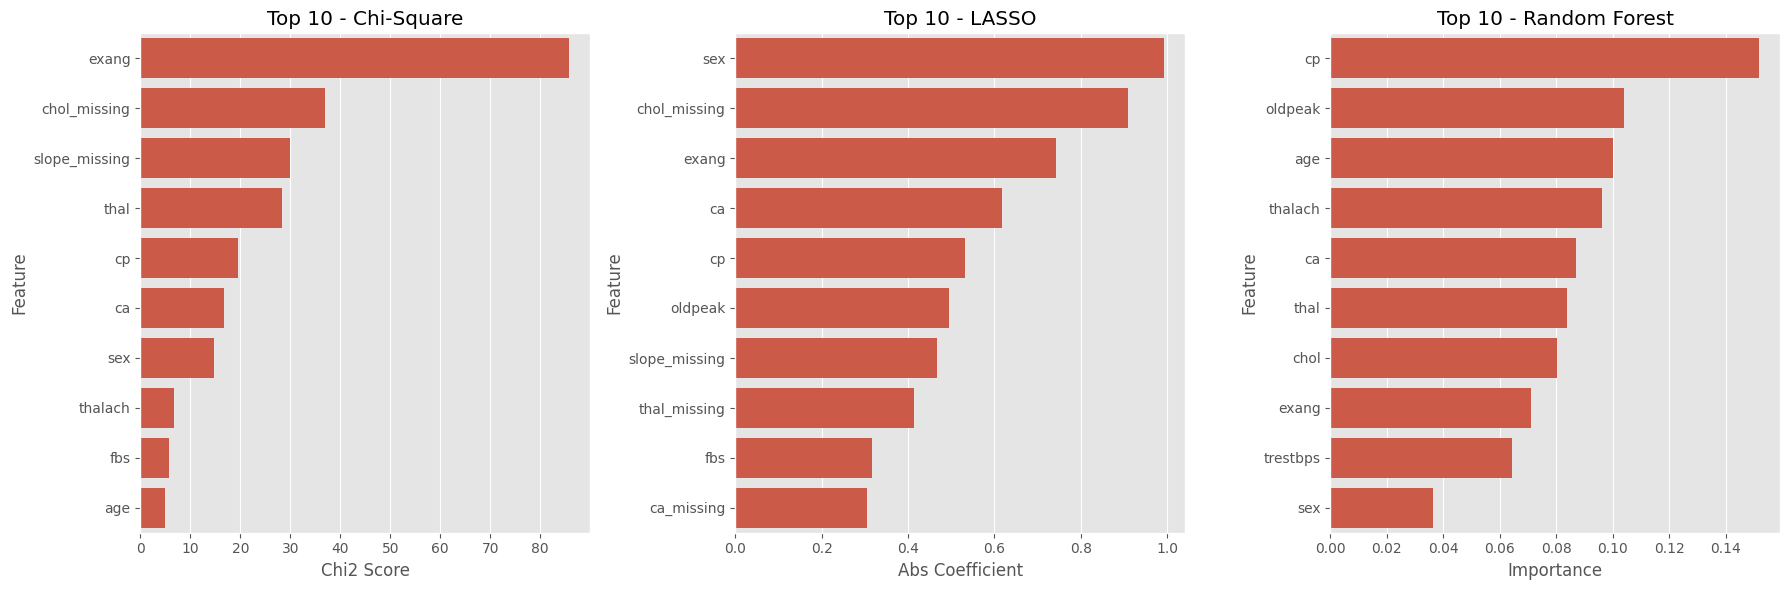

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18,6))

sns.barplot(data=chi_df.head(10), x="Chi2 Score", y="Feature", ax=axes[0])
axes[0].set_title("Top 10 - Chi-Square")

sns.barplot(data=lasso_df.head(10), x="Abs Coefficient", y="Feature", ax=axes[1])
axes[1].set_title("Top 10 - LASSO")

sns.barplot(data=rf_df.head(10), x="Importance", y="Feature", ax=axes[2])
axes[2].set_title("Top 10 - Random Forest")

plt.tight_layout()
plt.savefig("4_feature_selection_comparison.png", dpi=150)
plt.show()

In [20]:
# ==========================================
# Final Feature Set (Consensus Selection)
# ==========================================

selected_features = [
    "cp",
    "exang",
    "ca",
    "sex",
    "chol_missing",
    "slope_missing",
    "thal",
    "thalach",
    "age",
    "oldpeak",
    "fbs"
]

selected_df = pd.DataFrame({
    "Feature": selected_features
})

selected_df

,Feature
0,cp
1,exang
2,ca
3,sex
4,chol_missing
5,slope_missing
6,thal
7,thalach
8,age
9,oldpeak


In [21]:
# ==========================================
# Save Results
# ==========================================

comparison.to_csv(
    "04_feature_comparison.csv",
    index=False
)

chi_df.to_csv(
    "04_chi2_scores.csv",
    index=False
)

lasso_df.to_csv(
    "04_lasso_coefficients.csv",
    index=False
)

rf_df.to_csv(
    "04_rf_importance.csv",
    index=False
)

selected_df.to_csv(
    "04_selected_features.csv",
    index=False
)

print("All files saved successfully.")

All files saved successfully.


In [23]:
# ==========================================
# Download Outputs
# ==========================================

from google.colab import files

download_files = [
    "04_feature_comparison.csv",
    "04_chi2_scores.csv",
    "04_lasso_coefficients.csv",
    "04_rf_importance.csv",
    "04_selected_features.csv",
    "4_feature_selection_comparison.png"
]

for file in download_files:
    files.download(file)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>